## EDA Objective

The goal of this Exploratory Data Analysis (EDA) is to rigorously examine patterns, relationships, and statistical signals in the cleaned diabetes hospitalization dataset in order to support the development of reliable and interpretable models for predicting 30-day hospital readmission.

All analyses are conducted with statistical discipline and uncertainty awareness, aiming to support conclusions.

# What we have done so far from the previous wrangling of our 30-day hospital readmission dataset and problem statement
A. Target definition
•Binary readmit_30d aligned with hospital quality metrics
•Correct exclusion of hospice/expired cases.

B. Missing data strategy
•Dropped >80% missing clinical fields (weight, A1Cresult, max_glu_serum)
•Preserved informative missingness using "Unknown" for categorical fields.

C. Diagnosis handling
•ICD-9 3-digit extraction for reducing sparsity while preserving disease category signal.

D. Medication feature engineering 
•Presence flag
•Ordinal dose encoding
•Dose-change instability signal.

(Medication feature engineering expanded the number of columns on purpose because one raw medication column actually contains multiple different signals, and collapsing them into a single column would lose information that matters for readmission risk)


E. No blind outlier removal
•Decision taken for given clinical meaning of extremes.

In [59]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import mannwhitneyu



sns.set(style="whitegrid")
df = pd.read_csv("data/clean/hospital_readmission_clean_v1.csv")

In [2]:
# To inspect sample rows from our dataset and view the entire list of columns completely since its over 100 columns
print(df.shape)
df.sample(10)

(99343, 114)


,medical_specialty,payer_code,race,diag_3,diag_2,diag_1,patient_nbr,time_in_hospital,admission_source_id,num_lab_procedures,...,glimepiride-pioglitazone_dose_change,metformin-rosiglitazone_flag,metformin-rosiglitazone_dose,metformin-rosiglitazone_dose_change,metformin-pioglitazone_flag,metformin-pioglitazone_dose,metformin-pioglitazone_dose_change,insulin_flag,insulin_dose,insulin_dose_change
36821,InternalMedicine,MC,AfricanAmerican,584,276,250.6,23228883,11,7,43,...,0,0,0,0,0,0,0,1,2,1
94204,Unknown,CP,Caucasian,285,403,250.8,160252277,3,7,46,...,0,0,0,0,0,0,0,0,0,0
23506,Unknown,Unknown,Caucasian,401,786,530,18151785,2,7,42,...,0,0,0,0,0,0,0,0,0,0
55443,Unknown,CP,Caucasian,V58,250,850,59460813,1,7,39,...,0,0,0,0,0,0,0,1,1,0
75966,Family/GeneralPractice,HM,Caucasian,537,197,151,37793520,8,1,50,...,0,0,0,0,0,0,0,1,2,1
38073,Unknown,Unknown,AfricanAmerican,250,295,401,113851566,2,17,70,...,0,0,0,0,0,0,0,0,0,0
96858,Unknown,HM,AfricanAmerican,403,599,584,84378636,3,7,35,...,0,0,0,0,0,0,0,0,0,0
59610,Cardiology,MC,Caucasian,250,413,414,42537402,1,1,40,...,0,0,0,0,0,0,0,0,0,0
57240,Unknown,MC,Caucasian,599,276,410,103957461,4,7,66,...,0,0,0,0,0,0,0,0,0,0
70390,Unknown,MC,Caucasian,584,428,53,40921659,7,1,61,...,0,0,0,0,0,0,0,1,3,1


In [3]:
# look at the distribution of the data
df.describe()

,patient_nbr,time_in_hospital,admission_source_id,num_lab_procedures,encounter_id,admission_type_id,discharge_disposition_id,number_inpatient,number_emergency,number_outpatient,...,glimepiride-pioglitazone_dose_change,metformin-rosiglitazone_flag,metformin-rosiglitazone_dose,metformin-rosiglitazone_dose_change,metformin-pioglitazone_flag,metformin-pioglitazone_dose,metformin-pioglitazone_dose_change,insulin_flag,insulin_dose,insulin_dose_change
count,9.934300e+04,99343.000000,99343.000000,99343.000000,9.934300e+04,99343.000000,99343.000000,99343.000000,99343.000000,99343.000000,...,99343.0,99343.000000,99343.000000,99343.0,99343.000000,99343.000000,99343.0,99343.000000,99343.000000,99343.000000
mean,5.426117e+07,4.379332,5.731083,42.906929,1.649689e+08,2.030259,3.517882,0.630935,0.198444,0.369246,...,0.0,0.000020,0.000020,0.0,0.000010,0.000010,0.0,0.533143,0.883474,0.230464
std,3.873426e+07,2.968409,4.065029,19.610032,1.026535e+08,1.446373,5.184359,1.260428,0.937734,1.265142,...,0.0,0.004487,0.004487,0.0,0.003173,0.003173,0.0,0.498903,1.021448,0.421132
min,1.350000e+02,1.000000,1.000000,1.000000,1.252200e+04,1.000000,1.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
25%,2.338675e+07,2.000000,1.000000,31.000000,8.469034e+07,1.000000,1.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
50%,4.541774e+07,4.000000,7.000000,44.000000,1.522321e+08,1.000000,1.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,1.000000,1.000000,0.000000
75%,8.756007e+07,6.000000,7.000000,57.000000,2.301018e+08,3.000000,3.000000,1.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,1.000000,1.000000,0.000000
max,1.895026e+08,14.000000,25.000000,132.000000,4.438672e+08,8.000000,28.000000,21.000000,76.000000,42.000000,...,0.0,1.000000,1.000000,0.0,1.000000,1.000000,0.0,1.000000,3.000000,1.000000


In [4]:
#Verify data integrity and identify discrepancies between stored data types and analytical meaning
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99343 entries, 0 to 99342
Columns: 114 entries, medical_specialty to insulin_dose_change
dtypes: int64(78), object(36)
memory usage: 86.4+ MB


In [5]:
# Reviewing our entire Numeric columns in our DataFrame 
pd.set_option('display.max_rows', 80)
pd.set_option('display.max_columns', 80)

df.select_dtypes(include='number').dtypes

patient_nbr                             int64
time_in_hospital                        int64
admission_source_id                     int64
num_lab_procedures                      int64
encounter_id                            int64
admission_type_id                       int64
discharge_disposition_id                int64
number_inpatient                        int64
number_emergency                        int64
number_outpatient                       int64
num_medications                         int64
num_procedures                          int64
number_diagnoses                        int64
readmit_30d                             int64
age_mid                                 int64
metformin_flag                          int64
metformin_dose                          int64
metformin_dose_change                   int64
repaglinide_flag                        int64
repaglinide_dose                        int64
repaglinide_dose_change                 int64
nateglinide_flag                  

In [6]:
# Reclasify some of our int64 dtype numerical features into proper context for meaningful use in our EDA and subsequently
# Classifying variables based on statistical meaning to guide correct visualization, testing, and encoding

categorical_features = [
    'admission_type_id',
    'discharge_disposition_id',
    'admission_source_id',
    'race',
    'gender'
]

numeric_features = [
    'time_in_hospital',
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_outpatient',
    'number_emergency',
    'number_inpatient'
]

ordinal_features = ['number_diagnoses']

Features were classified by semantic meaning rather than storage type to ensure statistically valid analysis. This prevents inappropriate use of distance-based methods on label-encoded variables

In [7]:
# Assess our target variable and identify implications for modeling and evaluation
target = 'readmit_30d'

df[target].value_counts(normalize=True)

readmit_30d
0    0.886112
1    0.113888
Name: proportion, dtype: float64

Readmission is relatively uncommon, indicating class imbalance.

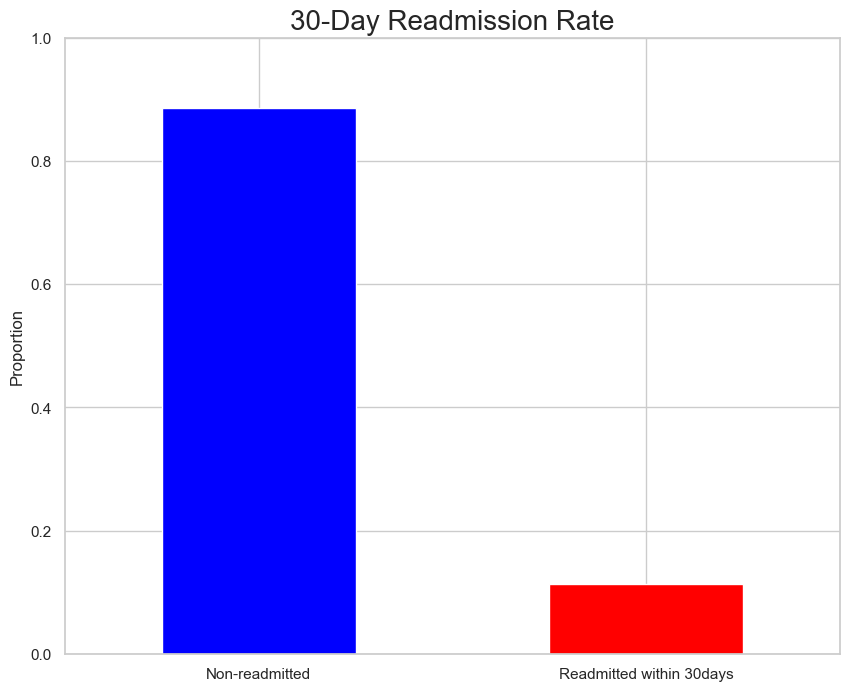

In [8]:
# Visually represent outcome proportions.
# Note that: 1 → readmitted within 30 days ("<30") and 0 → not readmitted within 30 days (">30" or "NO")

target_counts = (
    df[target]
    .value_counts(normalize=True)
    .sort_index()
)

target_counts.index = ['Non-readmitted', 'Readmitted within 30days']

plt.figure(figsize=(10, 8))
target_counts.plot(kind='bar', color=['blue', 'red'])

plt.title("30-Day Readmission Rate", fontsize=20)
plt.ylabel("Proportion")
plt.xlabel("")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.show()

Approximately 11-12% of encounters result in 30-day readmission confirms a class-imbalanced classification problem and justifies using stratified sampling, ROC-AUC, recall, and precision as primary metrics for future modelling evaluation metrics.

In [9]:
# Univariate numeric summary

df[numeric_features].describe()

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient
count,99343.000000,99343.000000,99343.000000,99343.000000,99343.000000,99343.000000,99343.000000
mean,4.379332,42.906929,1.334236,15.979062,0.369246,0.198444,0.630935
std,2.968409,19.610032,1.702786,8.094909,1.265142,0.937734,1.260428
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000
50%,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000
75%,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000
max,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000


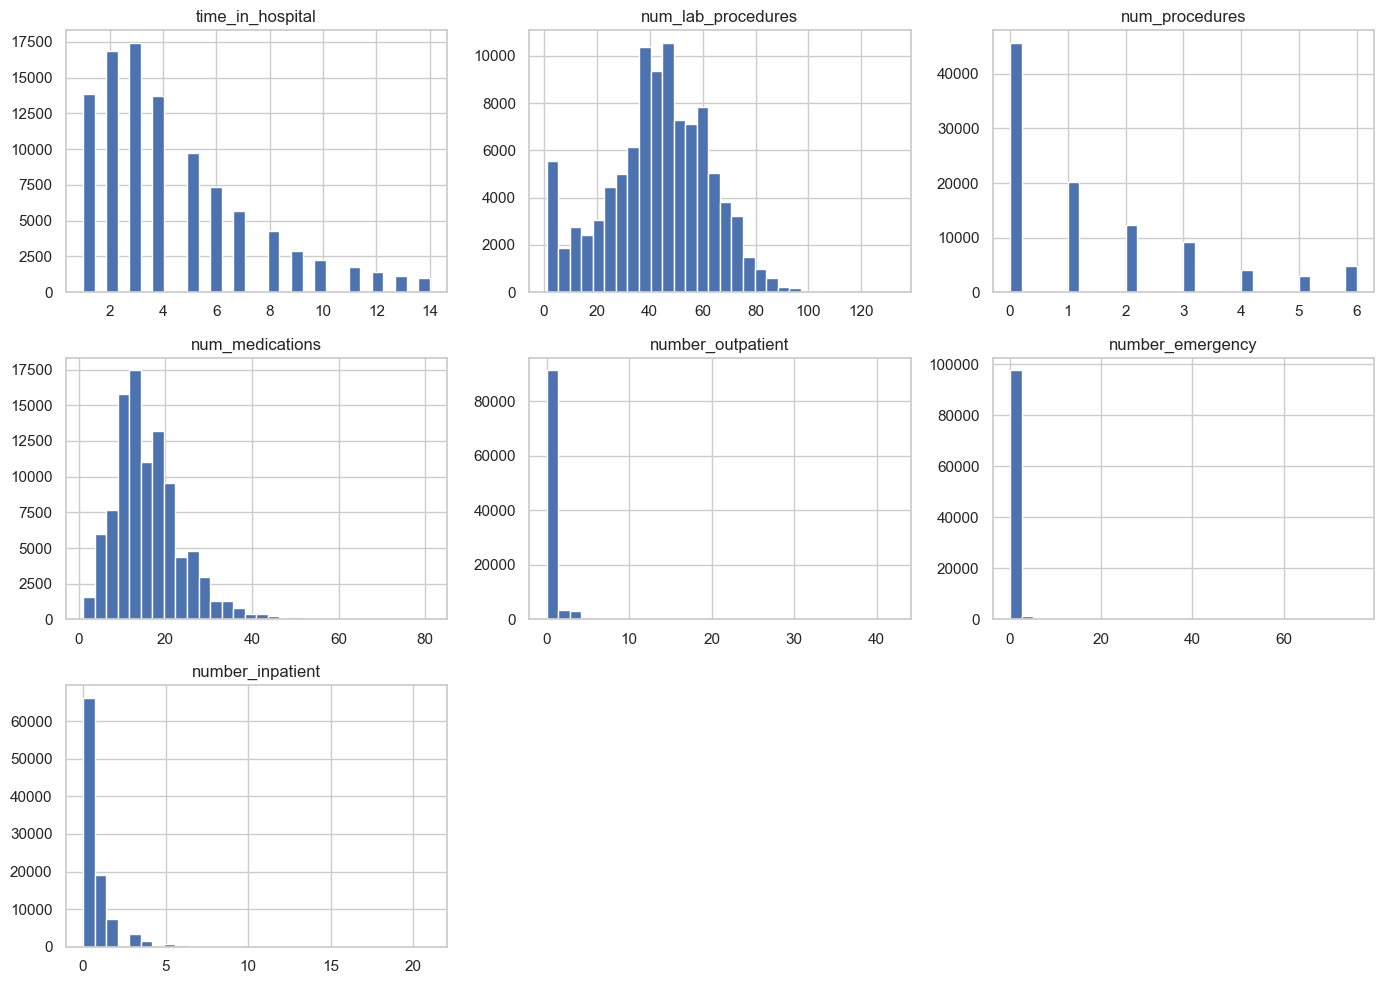

In [10]:
# Numeric distribution inspection using histograms

df[numeric_features].hist(bins=30, figsize=(14,10))
plt.tight_layout()
plt.show()

From the histogram its clear that most count variables are Right-skewness with heavy spikes at zero for: number_outpatient, number_emergency, number_inpatient while long right tails for: num_medications, num_lab_procedures

We can deduce that our distribution is a Non-normal distribution that is suitable for non-parametric tests and potentially require log-transformations.

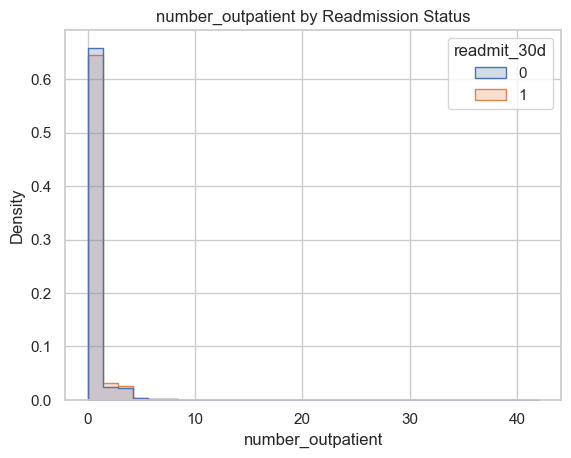

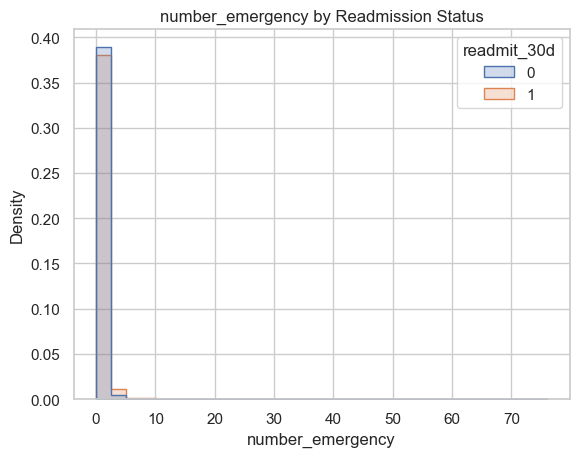

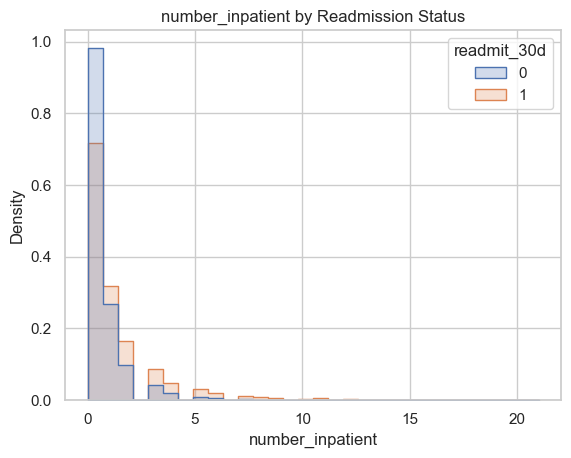

In [22]:
# To determine if previous healthcare usage intensity differs by readmission outcome
# Note that: 1 → readmitted within 30 days ("<30") and 0 → not readmitted within 30 days (">30" or "NO")

for col in ['number_outpatient','number_emergency','number_inpatient']:
    sns.histplot(x=col, data=df, hue=target, bins=30, stat='density', element='step',common_norm=False)
    plt.title(f"{col} by Readmission Status")
    plt.show()



Readmitted patients typically show heavier right tail while non-readmitted patients dominate near zero. There is substantial overlap across distributions because utilization intensity contributes risk, but is not deterministically predictive. Our histograms indicate that prior utilization distributions are largely overlapping across outcome groups. While minor distributional differences may exist, no strong univariate separation is visually apparent.

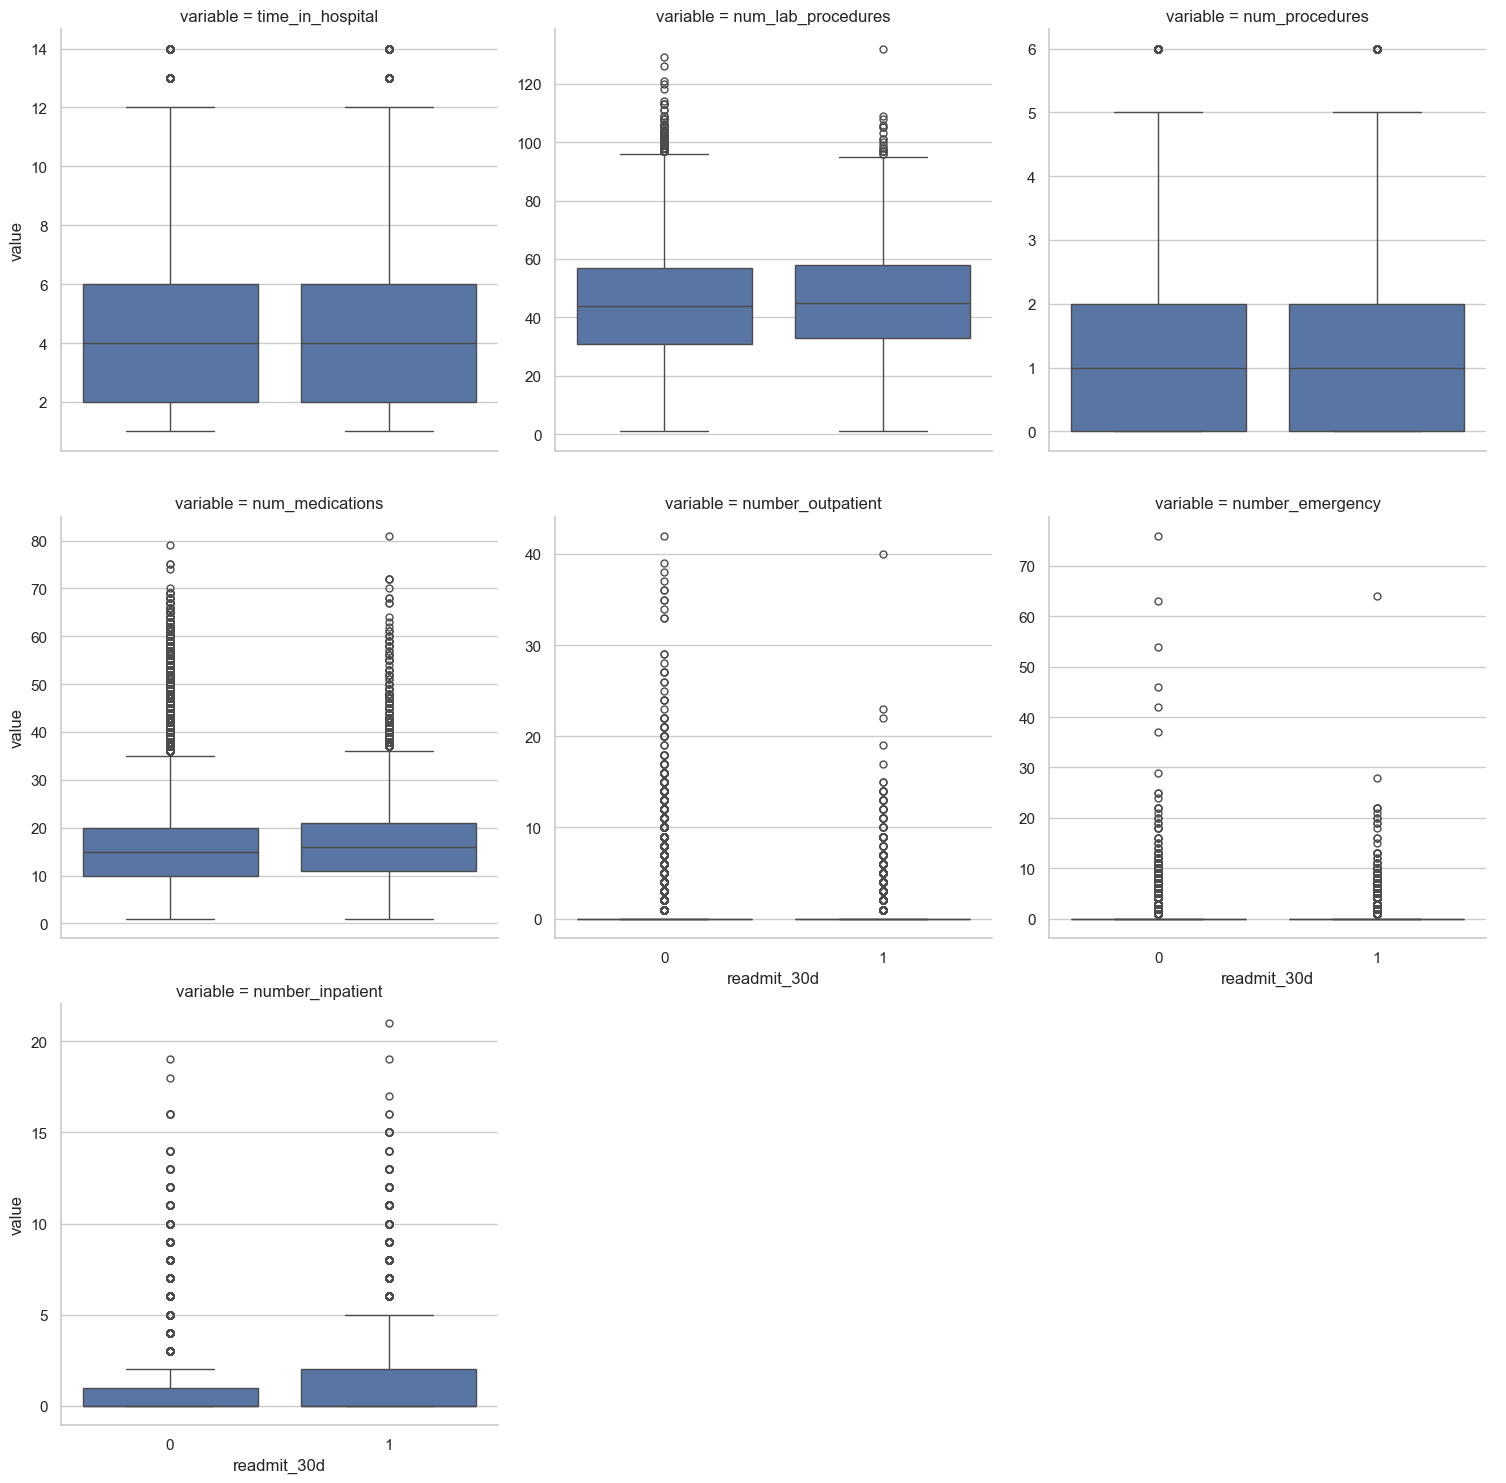

In [20]:
# Compare groups while minimizing the impact of outliers

melted = df.melt(id_vars=target, value_vars=numeric_features)

g = sns.catplot(
    data=melted,
    x=target,
    y="value",
    col="variable",
    kind="box",
    col_wrap=3,
    sharey=False,
    order=sorted(df[target].unique()
))

g.fig.tight_layout()
plt.show()


Most variables show substantial overlap between classes, only number_inpatient shows a clear upward shift in the readmitted group.This suggests that many features individually are weak separators and that readmission likely depends on combined feature interaction, not single-variable dominance.

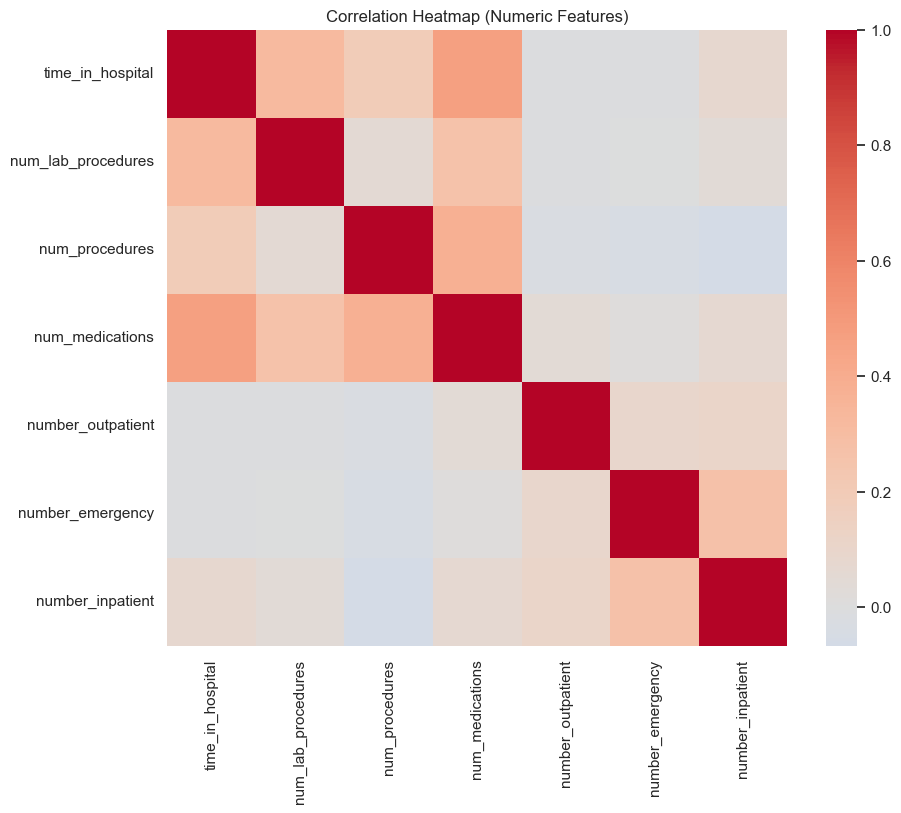

In [23]:
# Assess multicollinearity and redundancy using Correlation Heatmap (Numeric Features)

plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_features].corr(), cmap='coolwarm', center=0)
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()


Correlation analysis indicated limited linear dependence among predictors, with most pairwise associations falling within the low-to-moderate range (approximately 0.2–0.5). 

The strongest relationships were observed among healthcare utilization variables (number_emergency, number_inpatient, number_outpatient) reflecting clinically coherent groupings where patients who use emergency services are somewhat more likely to have inpatient admissions and outpatient follow-ups. 

Treatment intensity features such as time_in_hospital, num_lab_procedures, num_medications, num_procedures also show moderate positive associations. 

However, no correlations were sufficiently high to raise multicollinearity concerns. Our predictors appear to provide complementary rather than redundant information.

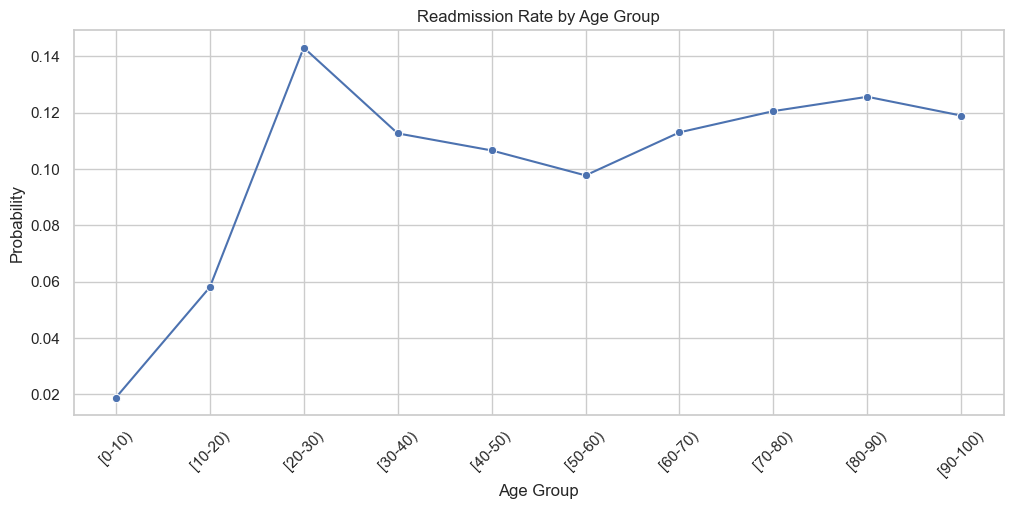

In [45]:
# Categorical Features vs Readmission
# To evaluate whether subgroups (Age Group Analysis) differ in readmission risk
# Line plot chosen to reveal progression pattern and subtle variation in readmission risk across age ranges

age_rate = (
    df.groupby('age_range')[target]
    .mean()
    .sort_index()
    .reset_index()
)

plt.figure(figsize=(12,5))

sns.lineplot(
    data=age_rate,
    x='age_range',
    y=target,
    marker='o'
)

plt.title("Readmission Rate by Age Group")
plt.ylabel("Probability")
plt.xlabel("Age Group")

plt.xticks(rotation=45)
plt.show()


Age-stratified analysis revealed non-linear variation in readmission probability. Pediatric populations exhibited low readmission rates, while a peak was observed in the 20–30 age group representing a sharp spike at ~14% (highest point). 

Risk stabilized during midlife and increased gradually among older adults. Although age demonstrates some association with readmission, the effect magnitude suggests it is unlikely to function as a strong standalone predictor.

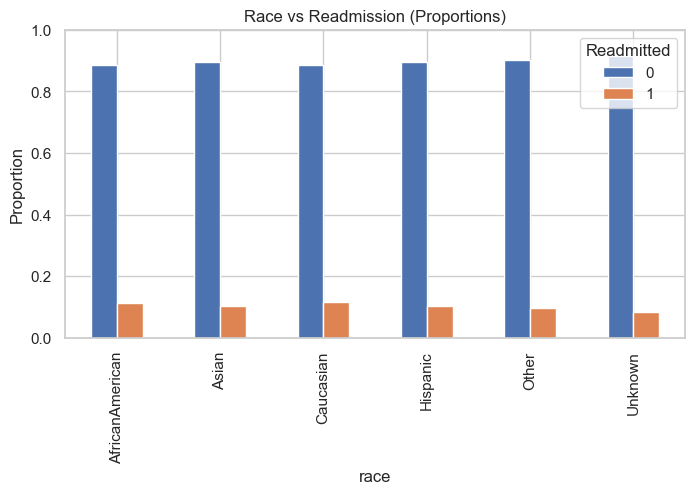

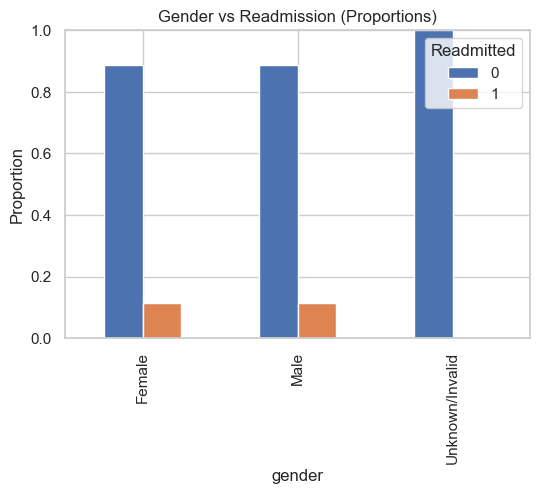

In [68]:
# Categorical Features vs Readmission

# Statistically on key demographics and readmission.

# ---- Race ----
race_prop = pd.crosstab(df['race'], df['readmit_30d'], normalize='index')

race_prop.plot(kind='bar', figsize=(8,4))
plt.title("Race vs Readmission (Proportions)")
plt.ylabel("Proportion")
plt.ylim(0,1)
plt.legend(title="Readmitted")
plt.show()


# ---- Gender ----
gender_prop = pd.crosstab(df['gender'], df['readmit_30d'], normalize='index')

gender_prop.plot(kind='bar', figsize=(6,4))
plt.title("Gender vs Readmission (Proportions)")
plt.ylabel("Proportion")
plt.ylim(0,1)
plt.legend(title="Readmitted")
plt.show()


In [69]:
# Statistical Test — Chi-Square

# ---- Race ----
race_table = pd.crosstab(df['race'], df['readmit_30d'])
chi2_race, p_race, _, _ = chi2_contingency(race_table)
print("Race p-value:", round(p_race, 6))

# ---- Gender ----
gender_table = pd.crosstab(df['gender'], df['readmit_30d'])
chi2_gender, p_gender, _, _ = chi2_contingency(gender_table)
print("Gender p-value:", round(p_gender, 6))

Race p-value: 5.6e-05
Gender p-value: 0.59786


For race, the p-value (5.6 × 10⁻⁵) is substantially below the 0.05 significance threshold, indicating strong statistical evidence against the null hypothesis of independence. This suggests that readmission rates vary significantly across racial groups.

For gender, the p-value (0.59786) exceeds the 0.05 threshold, indicating insufficient evidence to reject the null hypothesis. Therefore, no statistically significant association was observed between gender and readmission status.

Overall, the analysis suggests that race is statistically associated with readmission, whereas gender does not demonstrate a significant relationship in this dataset.

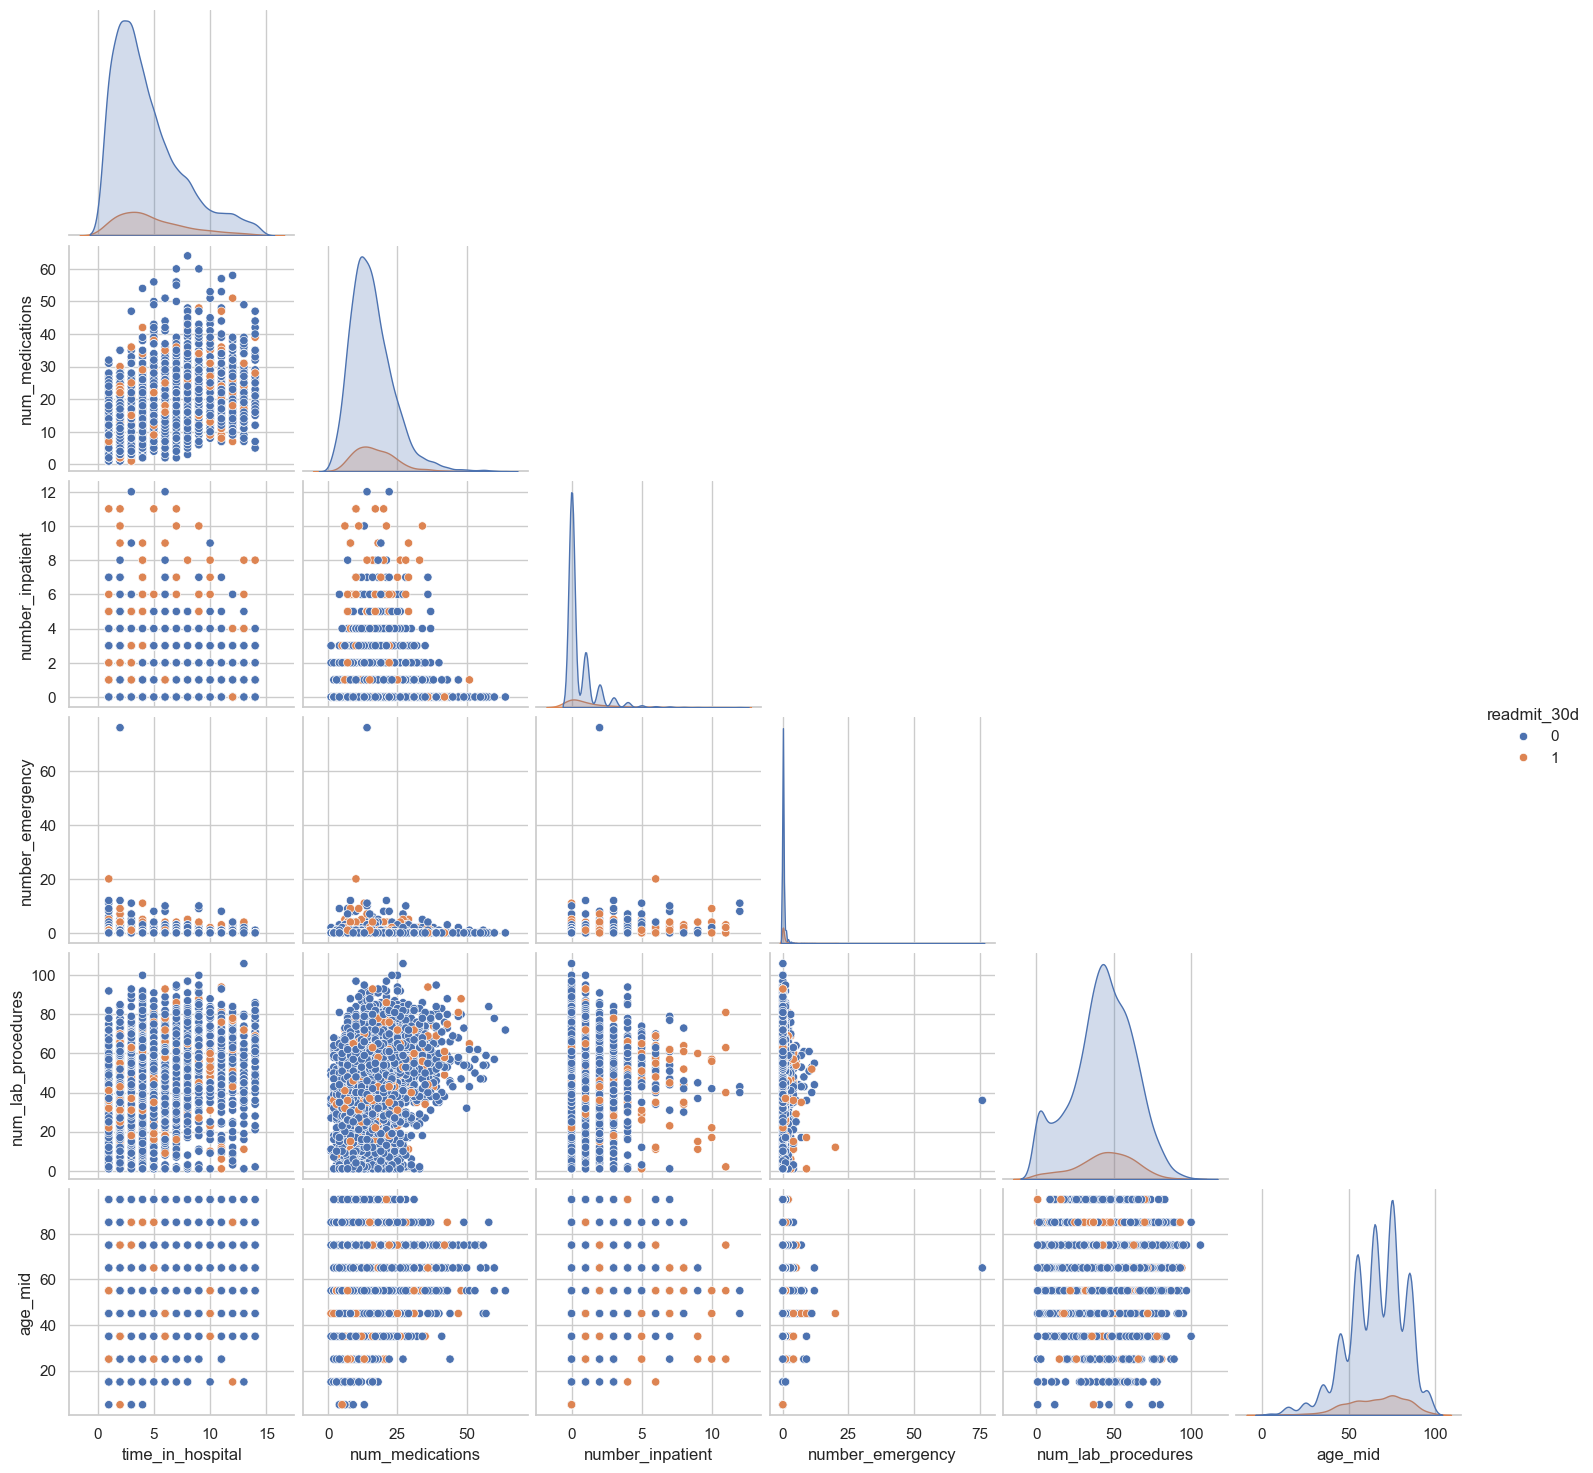

In [12]:
# Inspect multivariate structure without artificial smoothing bias.

# My Pairplots was restricted to clinically meaningful numeric variables to avoid noise, remain interpretable, maintain computational feasibility.
# due to the large dataset that has 114 features and ~100k rows. 

pair_cols = [
    'time_in_hospital',
    'num_medications',
    'number_inpatient',
    'number_emergency',
    'num_procedures',
    'number_outpatient',
    'num_lab_procedures',
    'age_mid'
]

# For computational efficiency and visual clarity, exploratory plots were generated using a reproducible random sample of 5,000 observations
sns.pairplot(
    df.sample(5000, random_state=42),
    vars=pair_cols,
    hue='readmit_30d',
    diag_kind='kde',
    corner=True,
)
plt.show()

The pairplot reveals substantial overlap between readmitted and non-readmitted patients across all individual predictors, readmission is driven by multiple weak signals, indicating the absence of a single dominant risk factor. Readmission risk increases modestly with longer hospital stays, higher medication counts, and prior inpatient utilization, with number_inpatient showing the clearest distributional shift. The predominantly discrete and skewed nature of the variables suggests non-linear and interaction-driven effects, supporting the use of tree-based or regularized models rather than reliance on linear separability.

# Saving our reproducible, leakage-free modeling dataset.
model_features = numeric_features + ordinal_features + categorical_features
df_model = df[model_features + [target]]
df_model.to_csv("readmission_model_ready.csv", index=False)
